In [1]:
!pip install ccxt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.4/155.4 kB 4.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.4/6.4 MB 82.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 219.6/219.6 kB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.6/216.6 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 68.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 48.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.1/131.1 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.4/132.4 kB 9.3 MB/s eta 0:00:00
  Attempting uninstall: urllib3
    Found existing installation: urllib3 2.5.0
    Uninstalling urllib3-2.5.0:
      Successfully uninstalled urllib3-2.5.0
  Attempting uninstall: setuptools
    Found existin

/tmp/ipykernel_1421/2082194634.py:126: UserWarning: Glyph 27169 (\N{CJK UNIFIED IDEOGRAPH-6A21}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1421/2082194634.py:126: UserWarning: Glyph 25311 (\N{CJK UNIFIED IDEOGRAPH-62DF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1421/2082194634.py:126: UserWarning: Glyph 26631 (\N{CJK UNIFIED IDEOGRAPH-6807}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1421/2082194634.py:126: UserWarning: Glyph 30340 (\N{CJK UNIFIED IDEOGRAPH-7684}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1421/2082194634.py:126: UserWarning: Glyph 20215 (\N{CJK UNIFIED IDEOGRAPH-4EF7}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1421/2082194634.py:126: UserWarning: Glyph 26684 (\N{CJK UNIFIED IDEOGRAPH-683C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1421/2082194634.py:126: UserWarning: Glyph 36208 (\N{CJK UNIFIED IDEOGRAP

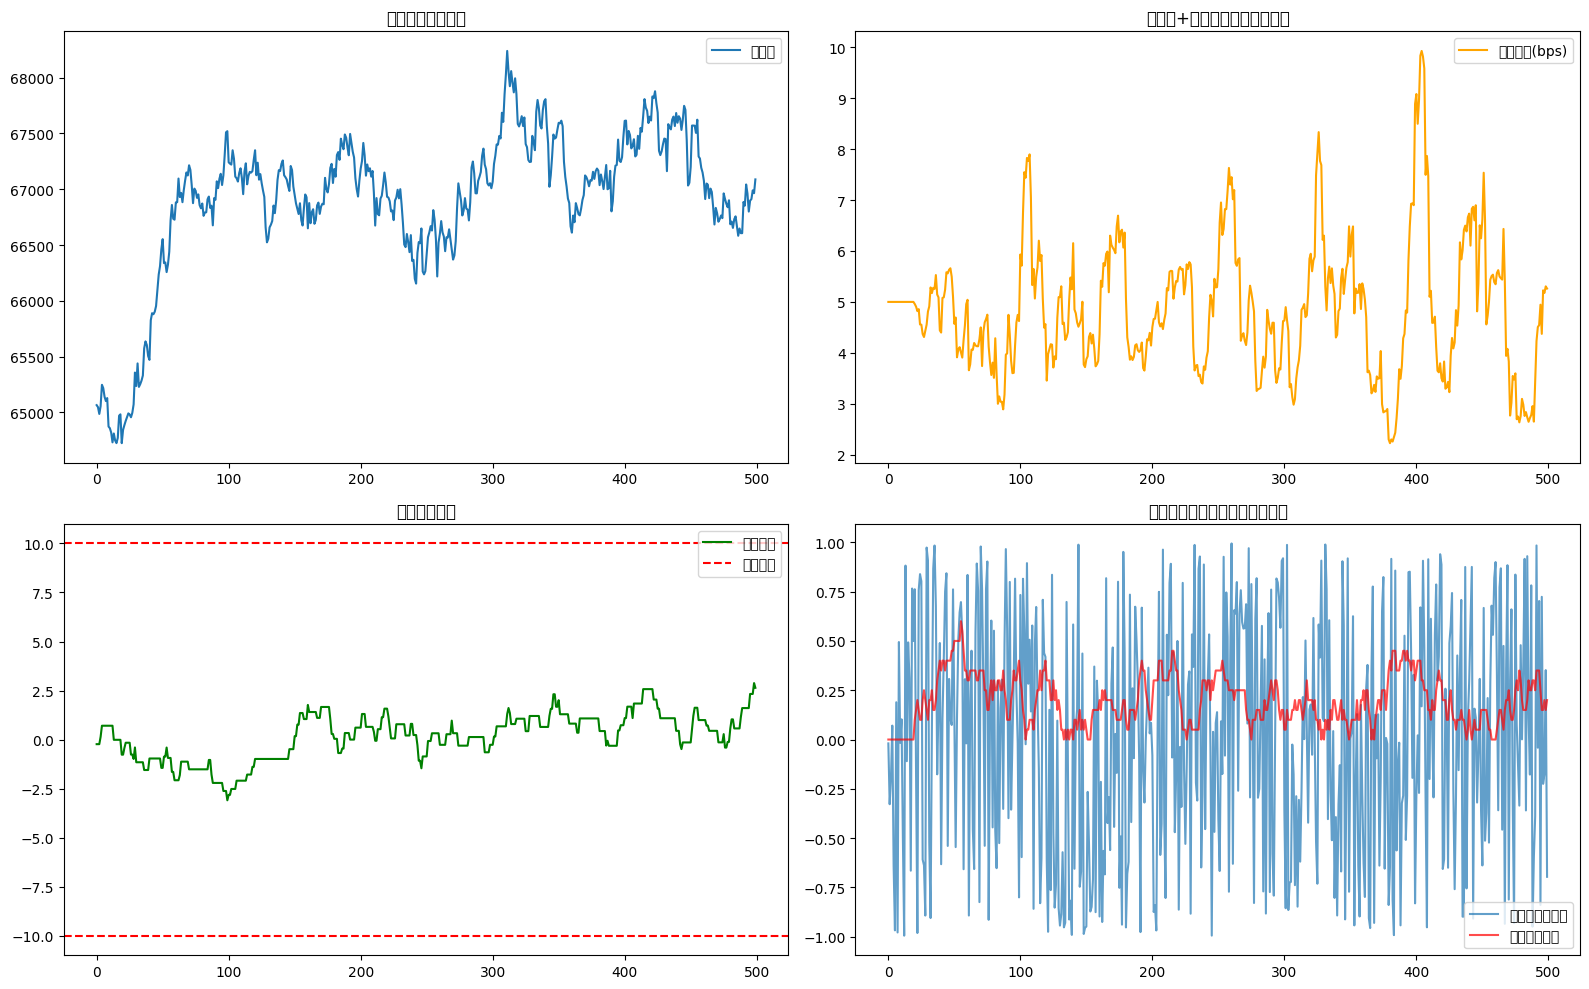

平均价差: 4.85 bps
价差范围: [2.23, 9.93] bps
平均偏移: -0.06 bps
最终库存: 2.64 BTC
最大绝对库存: 3.10 BTC


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# 订单簿不平衡信号
def imbalance_signal(bid_vol, ask_vol):
    total = bid_vol + ask_vol
    if total == 0:
        return 0
    return (bid_vol - ask_vol) / total

# 逆向选择毒性信号（修正逻辑：数值越大代表订单流毒性越强）
def toxicity_signal(trade_flow, window=20):
    if len(trade_flow) < window:
        return 0
    recent = np.mean(trade_flow[-window:])
    toxicity = abs(recent)
    return toxicity

# 波动率比值信号（滚动基准波动率，避免固定历史基准失真）
def vol_ratio_signal(returns, window=20):
    if len(returns) < window:
        return 1.0
    recent_vol = np.std(returns[-window:])
    # 滚动基准区间
    if len(returns) >= 2 * window:
        baseline_vol = np.std(returns[-2*window:-window])
    else:
        baseline_vol = np.std(returns[:window])
    if baseline_vol == 0:
        return 1.0
    return recent_vol / baseline_vol

# 信号融合报价引擎
def quote_engine(mid, inventory, max_inv,
                 imbalance, toxicity, vol_ratio,
                 base_bps=5, inv_scale=1.0):
    spread_bps = base_bps * vol_ratio
    # 毒性越高，收缩价差，压缩知情交易者套利空间
    spread_bps *= (1 - toxicity * 0.3)
    # 价差下限保护，防止价差归零失去盈利空间
    spread_bps = max(spread_bps, 0.1)

    inv_ratio = inventory / max_inv if max_inv != 0 else 0
    inv_skew = -inv_ratio * inv_scale * base_bps
    ob_skew = imbalance * base_bps * 0.3
    total_skew = inv_skew + ob_skew

    half_sp = mid * spread_bps / 10000 / 2
    skew_adj = total_skew * mid / 10000
    bid = mid - half_sp + skew_adj
    ask = mid + half_sp + skew_adj
    return bid, ask, spread_bps, total_skew

# 模拟初始化
np.random.seed(42)
n = 500
mid = 65000.0
inventory = 0.0
max_inv = 10.0
base_bps = 5

prices, bids, asks, invs = [], [], [], []
spreads, skews = [], []
imb_sig, tox_sig = [], []
returns, trade_flow = [], []

for t in range(n):
    ret = np.random.normal(0, 0.002)
    mid *= (1 + ret)
    returns.append(ret)
    prices.append(mid)

    # 模拟盘口买卖深度
    bid_vol = np.random.exponential(10) * (1 + 0.5*np.sin(t/30))
    ask_vol = np.random.exponential(10) * (1 + 0.5*np.cos(t/30))
    imb = imbalance_signal(bid_vol, ask_vol)
    imb_sig.append(imb)

    # 模拟订单流，周期性生成连续同向有毒知情订单，避免数据过度平滑失真
    if t % 60 < 10:
        side = np.random.choice([-1, 1], p=[0.5,0.5])
    else:
        side = np.random.choice([-1, 0, 1], p=[0.2, 0.4, 0.4])
    trade_flow.append(side)
    tox = toxicity_signal(trade_flow)
    tox_sig.append(tox)

    vol_r = vol_ratio_signal(returns)
    bid, ask, sp, sk = quote_engine(
        mid, inventory, max_inv,
        imb, tox, vol_r, base_bps)
    bids.append(bid)
    asks.append(ask)
    spreads.append(sp)
    skews.append(sk)

    # 随机浮动成交数量，替代固定单笔成交量，贴近真实市场
    if np.random.random() < 0.3:
        trade_size = np.random.uniform(0.2, 0.8)
        inventory += trade_size if np.random.random() < 0.5 else -trade_size
    invs.append(inventory)

# 绘图可视化代码
plt.rcParams['font.sans-serif'] = ['SimHei']
fig, axes = plt.subplots(2,2, figsize=(16,10))

axes[0,0].plot(prices, label='中间价')
axes[0,0].set_title('模拟标的价格走势')
axes[0,0].legend()

axes[0,1].plot(spreads, label='动态价差(bps)', color='orange')
axes[0,1].set_title('波动率+毒性双重调节价差变化')
axes[0,1].legend()

axes[1,0].plot(invs, label='库存持仓', color='green')
axes[1,0].axhline(max_inv, c='r', ls='--', label='库存上限')
axes[1,0].axhline(-max_inv, c='r', ls='--')
axes[1,0].set_title('库存变化曲线')
axes[1,0].legend()

axes[1,1].plot(imb_sig, label='订单簿不平衡度', alpha=0.7)
axes[1,1].plot(tox_sig, label='逆向选择毒性', alpha=0.7, c='red')
axes[1,1].set_title('订单不平衡、毒性信号时序曲线')
axes[1,1].legend()

plt.tight_layout()
plt.show()

# 批量输出回测统计指标
avg_spread = np.mean(spreads)
min_spread, max_spread = np.min(spreads), np.max(spreads)
avg_skew = np.mean(skews)
final_inv = invs[-1]
max_abs_inv = np.max(np.abs(invs))

print(f"平均价差: {avg_spread:.2f} bps")
print(f"价差范围: [{min_spread:.2f}, {max_spread:.2f}] bps")
print(f"平均偏移: {avg_skew:.2f} bps")
print(f"最终库存: {final_inv:.2f} BTC")
print(f"最大绝对库存: {max_abs_inv:.2f} BTC")